# Unbinned maximum likelihood fit

The probability densitiy function for the distribution of an angle $\alpha$ is given by

$$ f(x; a) = \frac{1 + a x}{2}, \quad x = \cos \alpha $$

The parameter $a$ is in the range $-1 \le a \le 1$.

## Tasks

a) Determine the maximum-likelihood estimate $\hat a$ of the parameter $a$ and its uncertainty from the provided data sample using a numerical minimization tool, e.g., `iminuit` (see comments below).

b) Plot the histogram representation of the data along with the fit function.

c) Determine the uncertainties $\sigma_a^-$ and $\sigma_a^+$ defined by

$$ \ln L (\hat a \pm \sigma_a) =  \ln L_\mathrm{max} - \frac{1}{2} $$

Compare your result with the result of `iminuit`'s `minos()` routine. Reduce the sample size of the data set by only taking the first $n$ events (`x[:n]`). At approximately which value of $n$ is the difference between $\sigma_a^-$ and $\sigma_a^+$ bigger than 5\%? 

Use the data generation provided in the notebook `S01_ml_02_generate_data.ipynb`. It is recommended to actually generate a `CSV` file and read it back here. You don't necessarily have to hand in your generated data; the tutors can generate their own and since your implemented procedure is generic, it should work with any other dataset generated with `S01_ml_02_generate_data.ipynb`.


### Hints

It is recommended to not start coding right away. Try to really understand how the Likelihood looks first. Realize, what the Likelihood is a function of and what it describes.

Also, the function imported as `from scipy.optimize import brentq` might come in handy.


## Comments on Python's `iminuit`

The KIP service has iminuit version 1.3.8. Please note that the most recent version is $\geq2.0.0$ and that the [documentation](https://iminuit.readthedocs.io/en/stable/) applies to *that* version. Some backward-incompatible changes have been introduced, some of which changed some interfaces. For your tasks that mainly affects the `minuit.Minuit` constructor. The following shows the construction of a `Minuit` object for version 1.3.8 (in case you use the KIP service or a version $<2.0.0$) and $\geq2.0.0$ (in case you use another service implementing a higher version), respectively.
```python
from iminuit import Minuit

def func(par1, par2, ..., parN):
    return minimise_something(par1, par2, ..., parN)

# least squares method: errordef=1
# likelihood method: errordef=0.5
m = Minuit(func, par1=0.1, par2=0.1, ..., parN=0.1, errordef=1)
```

And this would be the equivalent workflow for versions >2.0.0
```python
from iminuit import Minuit

def func(par1, par2, ..., parN):
    return minimise_something(par1, par2, ..., parN)

# least squares method: errordef=Minuit.LEAST_SQUARES
# likelihood method: errordef=Minuit.LIKELIHOOD

# add errordef as an attribute of your defined minimisation function which will be checked for when optimised
func.errordef = Minuit.LEAST_SQUARES
m = Minuit(func, par1=0.1, par2=0.1, ..., parN=0.1)
```

Another (potenitally) Jupiter related *feature* is the fact that `m.migrad()`, `m.matrix()`, `m.minos()` etc. can yield a nice summary of the respective procedure. However, in order to show it, either of these methods (and potentially others in case you use them) have to be *the last line of a code cell*. If there is *anything* coming afterwards, the output will not be printed, hence, for anything that follows, it is recommended to start a new code cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit

In [2]:
x = np.loadtxt("ml_fit_data.csv")

## Solutions

### MLE of $\hat{a}$ using `iminuit`

a) Determine the maximum-likelihood estimate $\hat a$ of the parameter $a$ and its uncertainty from the provided data sample using a numerical minimization tool, e.g., `iminuit` (see comments below).

We are given the function for the distribution of $x$:

$$ f(x; a) = \frac{1 + a x}{2} $$

For a dataset $\vec{x}$ with $n$ values, the log-likelihood of is therefore:

\begin{align*}
    \ln L(\vec{x}; a) &= \sum \limits_{i=1}^{n} \ln f(\vec{x}; a) \\
    \ln L(\vec{x}; a) &= \sum \limits_{i=1}^{n} \ln \frac{1 + a x_i}{2}
\end{align*}

In [3]:
# the given distribution of x for (fit-) parameter a
def dist_func(x, a):
    return (1 + a * x)/2

# log of likelihood function is sum of the log of the likelihoods of each value in data (vectorized function)
def log_likelihood(x_data, a):
    a = np.atleast_1d(a)
    x_data = np.atleast_1d(x_data)
    prob = dist_func(x_data[:, None], a[None, :])
    with np.errstate(invalid='ignore'):
        log_prob = np.log(prob)
    return np.sum(log_prob, axis = 0)

In [4]:
# iminuit minimizes, so the function needs to be negated
def negated_lllh_for_minuit(a):
    return (-log_likelihood(x, a))[0]

m = Minuit(negated_lllh_for_minuit, a = -1)
# for MLE, error needs to be set
m.errordef = Minuit.LIKELIHOOD
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 686.5                      │              Nfcn = 30               │
│ EDM = 3.82e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.19    │   0.05    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────┐
│   │       a │
├───┼─────────┤
│ a │ 0.00273 │
└───┴─────────┘

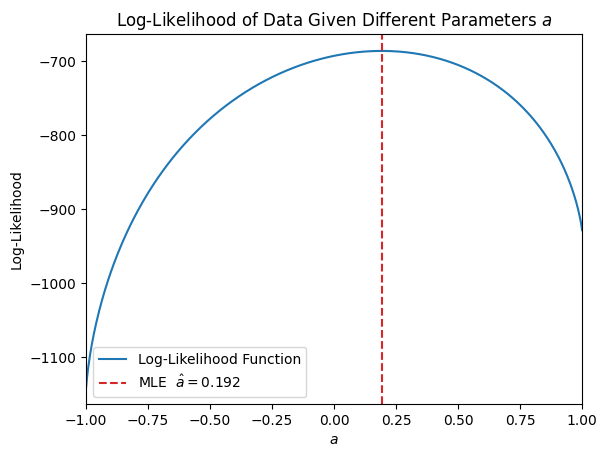

In [5]:
# read out a_hat MLE parameter and the resulting maximum log-likelihood
a_param = m.values[0]
lllh_max = log_likelihood(x, a_param)

# plot lllh function for dataset x, and MLE result a_param (a_hat)
alims = (-1, 1)
a_grid = np.linspace(*alims, 500)
lllh_grid = log_likelihood(x, a_grid)
plt.plot(a_grid, lllh_grid, label = 'Log-Likelihood Function')
plt.axvline(a_param, ls = 'dashed', color = 'tab:red', label = f'MLE  $\\hat{{a}} = {np.round(a_param, 3)}$')
plt.title(r'Log-Likelihood of Data Given Different Parameters $a$')
plt.xlabel(r'$a$')
plt.ylabel('Log-Likelihood')
plt.xlim(alims)
plt.legend(loc = 'lower left');

### Histogram of Data with Fit Function

b) Plot the histogram representation of the data along with the fit function.


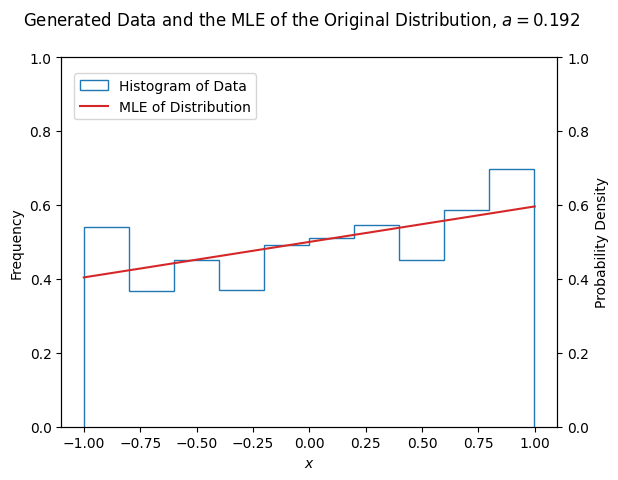

In [6]:
grid = np.linspace(-1, 1, 200)

fig, ax1 = plt.subplots()

ax1.set_xlabel(r'$x$')

ax1.hist(x, 10, histtype='step', density=True, label = 'Histogram of Data')
ax1.set_ylim((0, 1))
ax1.set_xlim((-1.1,1.1))
ax1.set_ylabel('Frequency')

ax2 = ax1.twinx()
ax2.plot(grid, dist_func(grid, a_param), color = 'tab:red', label = 'MLE of Distribution')
ax2.set_ylim((0, 1))
ax2.set_ylabel('Probability Density')

fig.suptitle(f'Generated Data and the MLE of the Original Distribution, $a = {np.round(a_param, 4)}$')
fig.legend(loc=(0.12, 0.75));

### Determining Uncertainties

c) Determine the uncertainties $\sigma_a^-$ and $\sigma_a^+$ defined by

$$ \ln L (\hat a \pm \sigma_a) =  \ln L_\mathrm{max} - \frac{1}{2} $$

Compare your result with the result of `iminuit`'s `minos()` routine. Reduce the sample size of the data set by only taking the first $n$ events (`x[:n]`). At approximately which value of $n$ is the difference between $\sigma_a^-$ and $\sigma_a^+$ bigger than $5\%$? 

In [7]:
val = lllh_max - 1/2
accuracy = 1
mylist = [
    (a, lllh)
    for a, lllh in zip(a_grid, lllh_grid)
    if np.round(lllh, accuracy) == np.round(val, accuracy)]

sigmas = np.zeros(2)
for i, (a, lllh) in enumerate(mylist):
    sigmas[i] = np.round(abs(a - a_param), 5)

print(sigmas)

[0.04974 0.05046]


In [8]:
m.minos()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 686.5                      │              Nfcn = 34               │
│ EDM = 3.82e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.19    │   0.05    │   -0.05    │    0.05    │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┐
│          │           a           │
├──────────┼───────────┬───────────┤
│  Error   │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │
│ At Limit │   False   │   False   │
│ Max FCN  │   False   │   False   │
│ New Min  │   False   │   False   │
└──────────┴───────────┴───────────┘
┌───┬─────────┐
│   │       a │
├───┼─────────┤
│ a │ 0.00273 │
└───┴─────────┘